## Model 2: Hierarchical table model (Stan)

**Idea:** same covariates as Model 1, but team skill combines long-run team quality and season-specific deviations, both measured **in points** (`tau_team`, `tau_season`).

**Backtest:** tables through 2024/25 → predict table 2025/26.

$$\text{Pts}_{s,t} \sim t_{\nu}\big(\alpha + \text{team\_skill}_{t} + \text{season\_dev}_{s,t} + \gamma^\top x_{s,t},\; \sigma_{\mathrm{pts}}\big)$$

with $x$ = (`sot_diff_pg`, `pts_lag1`, `ppg_last10`, z-scored) plus `is_promoted`, and sum-to-zero constraints for identifiable team and season effects.
Student-$t$ with $\nu=5$ fixed; $\tau_{\mathrm{team}}$ controls persistent team strength and $\tau_{\mathrm{season}}$ controls season-specific deviations.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
from cmdstanpy import CmdStanModel

import importlib
import helping_functions as hf
importlib.reload(hf)

from helping_functions import (
    load_matches,
    load_season_tables,
    prepare_table_stan_hierarchical,
    build_forecast_features,
    compute_table,
    predict_table,
    teams_in_season,
    STUDENT_T_NU,
    BACKTEST_TRAIN_SEASONS,
    BACKTEST_TEST_SEASON,
)


In [2]:
matches = load_matches()
TRAIN_SEASONS = BACKTEST_TRAIN_SEASONS
TEST_SEASON = BACKTEST_TEST_SEASON
LAST_TRAIN_SEASON = "2425"

tables = load_season_tables(matches, TRAIN_SEASONS)
stan_data, team_to_idx, train_teams, season_to_idx, feature_stats = (
    prepare_table_stan_hierarchical(tables, TRAIN_SEASONS)
)
stan_data["nu"] = STUDENT_T_NU
test_teams = sorted(teams_in_season(matches, TEST_SEASON))
last_season_idx = season_to_idx[LAST_TRAIN_SEASON]

print(f"Rows: {stan_data['N']}, seasons S={stan_data['S']}, teams T={stan_data['T']}")
print(f"Forecast uses season {LAST_TRAIN_SEASON} (index {last_season_idx})")


Rows: 320, seasons S=16, teams T=42
Forecast uses season 2425 (index 16)


### Prior selection (Model 2)

| Parameter | Prior | Expert rationale |
|-----------|-------|------------------|
| `intercept` | $\mathcal{N}(52, 10)$ | Baseline around the average points total in a 20-team Premier League season. |
| `beta_sot`, `beta_form` | $\mathcal{N}(0, 8)$ | Process/form effects on z-scored inputs; broad points-scale effects are allowed. |
| `beta_lag` | $\mathcal{N}(0, 0.5)$ | Conservative lagged-points effect because persistent quality is captured by `team_skill`. |
| `beta_promoted` | $\mathcal{N}(-10, 5)$ | Promoted-team penalty; allows large penalty, small penalty, or near-zero effect if data support it. |
| `log_sigma_pts` | $\mathcal{N}(\log 4.5, 0.12)$ | After team skill + covariates, unpredictable season noise is expected to be about 4-6 Student-$t$ scale points. |
| `log_tau_team` | $\mathcal{N}(\log 7, 0.20)$ | Persistent residual team-strength spread beyond process metrics. |
| `log_tau_season` | $\mathcal{N}(\log 2.25, 0.18)$ | Small season-specific deviations around long-run team strength. |
| `team_skill_z`, `season_dev_z` | sum-to-zero standard Normal vectors | Non-centered geometry with interpretable points-scale multipliers. |

The hierarchy is:

$\text{skill_obs}_{n} = \text{team_skill}_{team[n]} + \tau_{season}\,\text{season_dev_z}_{season[n],obs\_pos[n]}$.

`team_skill` captures long-run residual quality, while `season_dev` captures one-season over/under-performance. Priors were chosen before model fitting from football scale: residual team differences of several points are plausible, but season-specific deviations should be smaller than persistent team quality.


### Prior predictive checks

The checks below separate two questions required by the rubric:

- **Parameter priors:** do `sigma_pts`, `tau_team`, `tau_season`, `beta_promoted`, and the other coefficients imply football-scale values?
- **Measurement priors:** after combining parameters with lag-safe covariates, do simulated team-season point totals look broadly plausible before conditioning on observed points?


,0.05,0.50,0.95
intercept,35.488292,51.988122,68.339934
beta_sot,-13.502537,-0.090220,13.067169
beta_lag,-0.830642,-0.001901,0.830535
beta_form,-13.129701,0.115849,13.201099
beta_promoted,-18.307420,-10.034826,-1.705441
sigma_pts,3.713142,4.512161,5.447889
tau_team,5.045715,6.997589,9.709438
tau_season,1.683996,2.245164,2.992160
team_skill_range,19.827318,30.059910,44.936105
season_dev_range,5.325704,8.217755,12.615562


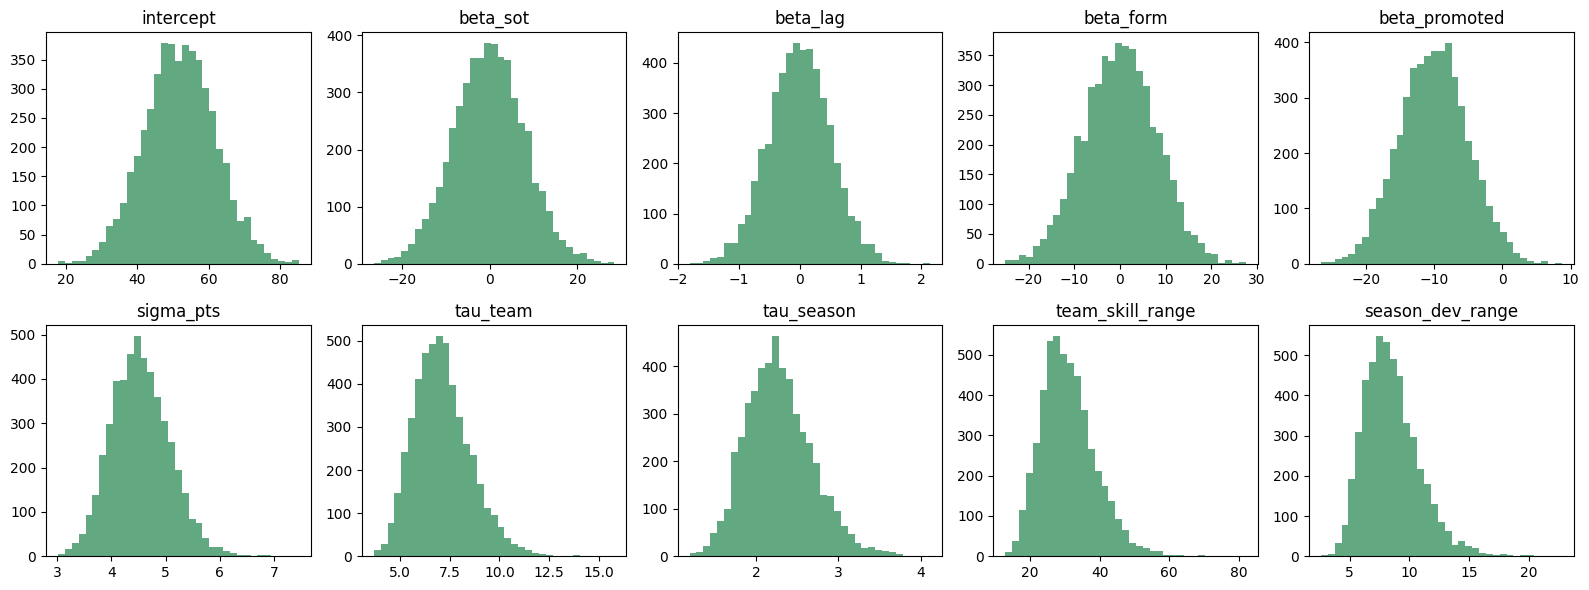

Prior points mean: 50.6; observed mean: 52.4
Prior central 90% interval: 19.7 to 79.7
Observed range: 12 to 100


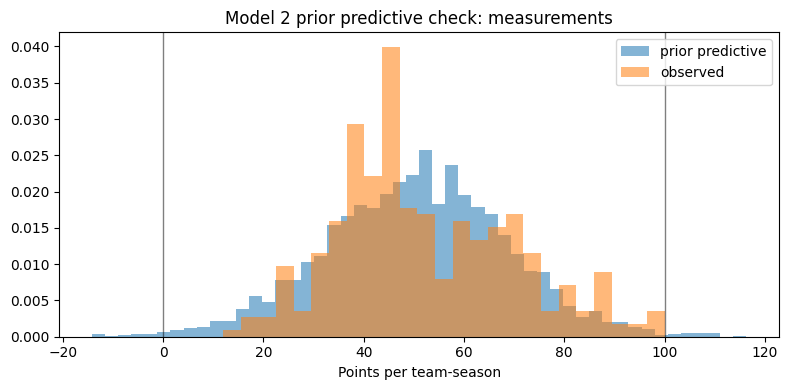

In [3]:
rng = np.random.default_rng(43)
n_prior = 5000
T = stan_data["T"]
S = stan_data["S"]
K = stan_data["K"]
nu_prior = STUDENT_T_NU

def rtrunc_normal(mean, sd, lower=-np.inf, upper=np.inf, size=1):
    out = np.empty(size)
    filled = 0
    while filled < size:
        draws = rng.normal(mean, sd, size - filled)
        draws = draws[(draws >= lower) & (draws <= upper)]
        take = min(len(draws), size - filled)
        if take:
            out[filled:filled + take] = draws[:take]
            filled += take
    return out

intercept_p = rng.normal(52, 10, n_prior)
beta_sot_p = rng.normal(0, 8, n_prior)
beta_lag_p = rng.normal(0, 0.5, n_prior)
beta_form_p = rng.normal(0, 8, n_prior)
beta_promoted_p = rng.normal(-10, 5, n_prior)

sigma_p = np.exp(rtrunc_normal(np.log(4.5), 0.12, lower=np.log(0.5), upper=np.log(20), size=n_prior))
tau_team_p = np.exp(rtrunc_normal(np.log(7), 0.20, lower=np.log(1), upper=np.log(25), size=n_prior))
tau_season_p = np.exp(rtrunc_normal(np.log(2.25), 0.18, lower=np.log(0.25), upper=np.log(15), size=n_prior))

team_skill_z = rng.normal(0, 1, (n_prior, T))
team_skill_z -= team_skill_z.mean(axis=1, keepdims=True)
team_skill = tau_team_p[:, None] * team_skill_z

season_dev_z = rng.normal(0, 1, (n_prior, K))
season_dev_z -= season_dev_z.mean(axis=1, keepdims=True)
season_dev = tau_season_p[:, None] * season_dev_z

prior_params = pd.DataFrame({
    "intercept": intercept_p,
    "beta_sot": beta_sot_p,
    "beta_lag": beta_lag_p,
    "beta_form": beta_form_p,
    "beta_promoted": beta_promoted_p,
    "sigma_pts": sigma_p,
    "tau_team": tau_team_p,
    "tau_season": tau_season_p,
    "team_skill_range": team_skill.max(axis=1) - team_skill.min(axis=1),
    "season_dev_range": season_dev.max(axis=1) - season_dev.min(axis=1),
})
display(prior_params.quantile([0.05, 0.5, 0.95]).T)

fig, axes = plt.subplots(2, 5, figsize=(16, 6))
for ax, col in zip(axes.ravel(), prior_params.columns):
    ax.hist(prior_params[col], bins=35, color="seagreen", alpha=0.75)
    ax.set_title(col)
plt.tight_layout()
plt.show()

# Measurement prior predictive: sample actual design rows, but draw parameters from prior.
idx = rng.integers(0, stan_data["N"], size=3000)
draw = rng.integers(0, n_prior, size=3000)
teams = np.asarray(stan_data["team"])[idx] - 1
obs_pos = np.asarray(stan_data["obs_pos"])[idx] - 1

skill_obs_prior = team_skill[draw, teams] + season_dev[draw, obs_pos]
mu_prior = (
    intercept_p[draw]
    + skill_obs_prior
    + beta_sot_p[draw] * np.asarray(stan_data["sot_diff_pg"])[idx]
    + beta_lag_p[draw] * np.asarray(stan_data["pts_lag1"])[idx]
    + beta_form_p[draw] * np.asarray(stan_data["ppg_last10"])[idx]
    + beta_promoted_p[draw] * np.asarray(stan_data["is_promoted"])[idx]
)
pts_prior = mu_prior + sigma_p[draw] * rng.standard_t(nu_prior, size=len(draw))

print(f"Prior points mean: {pts_prior.mean():.1f}; observed mean: {np.mean(stan_data['pts']):.1f}")
print(f"Prior central 90% interval: {np.quantile(pts_prior, 0.05):.1f} to {np.quantile(pts_prior, 0.95):.1f}")
print(f"Observed range: {np.min(stan_data['pts']):.0f} to {np.max(stan_data['pts']):.0f}")

plt.figure(figsize=(8, 4))
plt.hist(pts_prior, bins=50, density=True, alpha=0.55, label="prior predictive")
plt.hist(stan_data["pts"], bins=25, density=True, alpha=0.55, label="observed")
plt.axvline(0, color="black", lw=1, alpha=0.5)
plt.axvline(100, color="black", lw=1, alpha=0.5)
plt.xlabel("Points per team-season")
plt.title("Model 2 prior predictive check: measurements")
plt.legend()
plt.tight_layout()
plt.show()


**Prior predictive interpretation (Model 2):** `tau_team` should dominate `tau_season`, because persistent club quality should vary more than one-year noise around that quality. `sigma_pts` should be smaller than raw table-point SD because the model already explains points with team quality and covariates. The measurement prior can be wider than observed data, but its central mass should describe plausible league seasons rather than impossible point totals.

In [4]:
model = CmdStanModel(stan_file="stan/table_hierarchical.stan")
fit = model.sample(
    data=stan_data,
    seed=42,
    chains=4,
    parallel_chains=4,
    iter_warmup=1500,
    iter_sampling=1500,
    adapt_delta=0.99,
    show_progress=True,
)
print(fit.diagnose())


16:03:30 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

16:03:38 - cmdstanpy - INFO - CmdStan done processing.



Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



### Sampling diagnostics

Check divergences (`fit.diagnose()` above), $\hat{R}$, and ESS.
Target: $\hat{R} \leq 1.01$, ESS bulk $\gtrsim 400$ per parameter.


                      Mean      MCSE     StdDev        MAD           5%  \
intercept        50.073400  0.014783   0.921467   0.912540    48.540300   
beta_sot          6.181780  0.012047   0.898325   0.899960     4.727460   
beta_lag         -0.015895  0.004299   0.477122   0.473441    -0.791540   
beta_form         1.086340  0.010685   0.941971   0.924575    -0.442062   
beta_promoted    -8.883550  0.028770   2.150100   2.142660   -12.403300   
sigma_pts         7.359210  0.010706   0.455241   0.436433     6.595120   
tau_team          7.461060  0.019157   1.003090   0.960725     5.902760   
tau_season        2.913580  0.020695   0.733470   0.669053     1.932500   
lp__          -1059.950000  0.515080  17.304900  16.960900 -1087.390000   

                       50%          95%  ESS_bulk  ESS_tail    R_hat  
intercept        50.067700    51.594000   3946.17   4255.87  1.00179  
beta_sot          6.176340     7.684160   5604.86   4968.66  1.00075  
beta_lag         -0.014957     0.757

,mean,sd,hdi_3%,hdi_97%,ess_bulk,ess_tail,r_hat
intercept,50.073,0.921,48.260,51.723,3946.0,4256.0,1.0
beta_sot,6.182,0.898,4.552,7.937,5605.0,4969.0,1.0
beta_lag,-0.016,0.477,-0.884,0.902,12263.0,4842.0,1.0
beta_form,1.086,0.942,-0.610,2.883,7884.0,4686.0,1.0
beta_promoted,-8.884,2.150,-12.807,-4.831,5639.0,4612.0,1.0
sigma_pts,7.359,0.455,6.533,8.237,1924.0,1837.0,1.0
tau_team,7.461,1.003,5.562,9.311,2767.0,3784.0,1.0
tau_season,2.914,0.733,1.740,4.381,1589.0,1323.0,1.0


Parameters with R-hat > 1.01: 0
Parameters with ESS_bulk < 400: 0


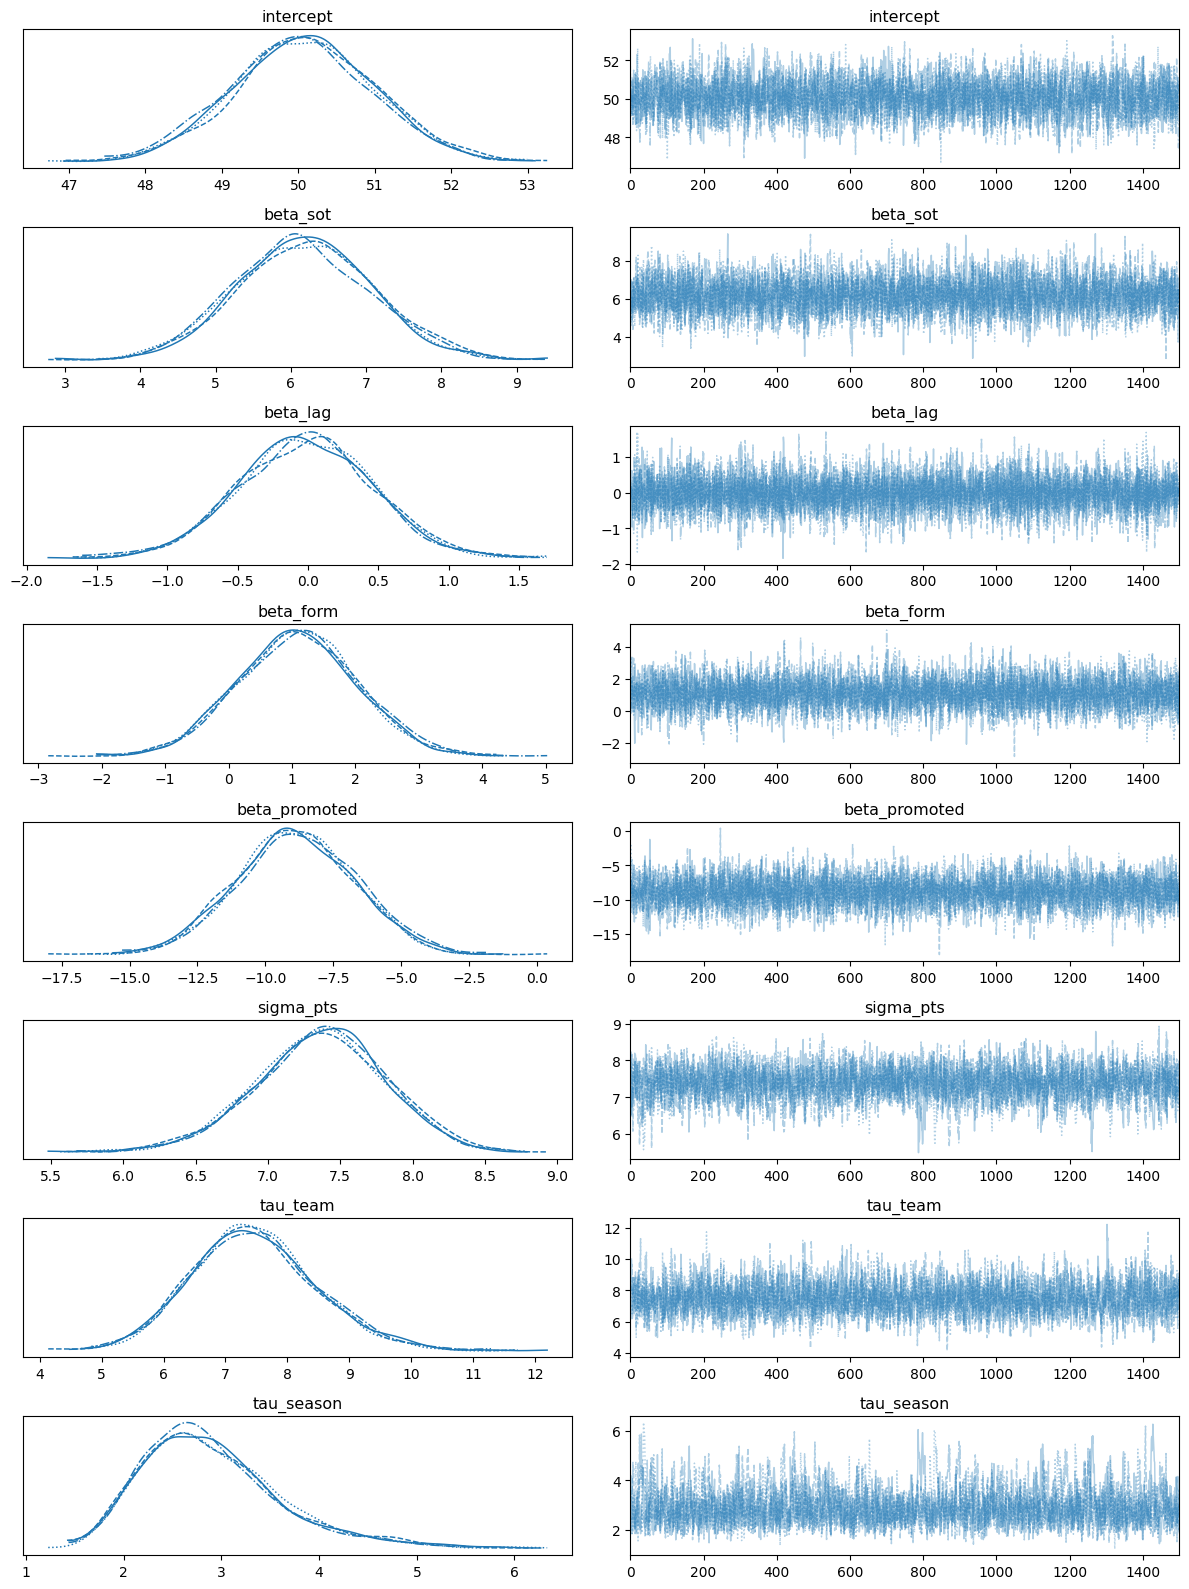

In [5]:
param_vars = [
    "intercept", "beta_sot", "beta_lag", "beta_form", "beta_promoted",
    "sigma_pts", "tau_team", "tau_season",
]
print(fit.summary().loc[param_vars + ["lp__"]])

idata = az.from_cmdstanpy(fit)
diag = az.summary(idata, var_names=param_vars)
cols = ["mean", "sd", "hdi_3%", "hdi_97%", "ess_bulk", "ess_tail", "r_hat"]
display(diag[cols])

bad_rhat = diag[diag["r_hat"] > 1.01]
low_ess = diag[diag["ess_bulk"] < 400]
print(f"Parameters with R-hat > 1.01: {len(bad_rhat)}")
if len(bad_rhat):
    display(bad_rhat[cols])
print(f"Parameters with ESS_bulk < 400: {len(low_ess)}")
if len(low_ess):
    display(low_ess[cols])

az.plot_trace(idata, var_names=param_vars, compact=True)
plt.tight_layout()
plt.show()


### Interpreting $\sigma_{\mathrm{pts}}$, $\tau_{\mathrm{team}}$, $\tau_{\mathrm{season}}$, and skills

| Parameter | Order of magnitude | Meaning |
|-----------|-------------------|---------|
| `tau_team` | ~6-10 pts | Persistent residual team quality beyond process metrics. |
| `tau_season` | ~1.5-3 pts | Season-specific deviation around long-run team quality. |
| `team_skill[t]` | roughly +/-15-25 pts range across clubs | Long-run residual club strength on the points scale. |
| `skill[s,t]` | `team_skill + season_dev` | Combined skill used for historical team-season rows. |
| `sigma_pts` | ~4-7 | Student-$t$ scale for leftover noise; approximate SD is $\sigma\sqrt{\nu/(\nu-2)}$. |

**Why $\sigma_{\mathrm{pts}} \ll 17$?** Around 17 points is close to the raw spread of final table points. In this model, team quality, promoted status, and lag-safe covariates explain much of that spread. `sigma_pts` is only the remaining unpredictable season noise.


In [6]:
s_idx = last_season_idx - 1
skill_last = fit.stan_variable("skill")[:, s_idx, :].mean(axis=0)
idx_to_team = {i: t for t, i in team_to_idx.items()}

pd.DataFrame({
    "team": [idx_to_team[j+1] for j in range(len(skill_last))],
    "skill": skill_last,
}).sort_values("skill", ascending=False).head(10)


,team,skill
22,Man City,17.190831
20,Liverpool,12.903052
0,Arsenal,12.774265
23,Man United,12.486186
11,Chelsea,11.795407
36,Tottenham,9.194714
7,Brentford,4.819755
1,Aston Villa,3.786099
25,Newcastle,3.509809
27,Nott'm Forest,3.110378


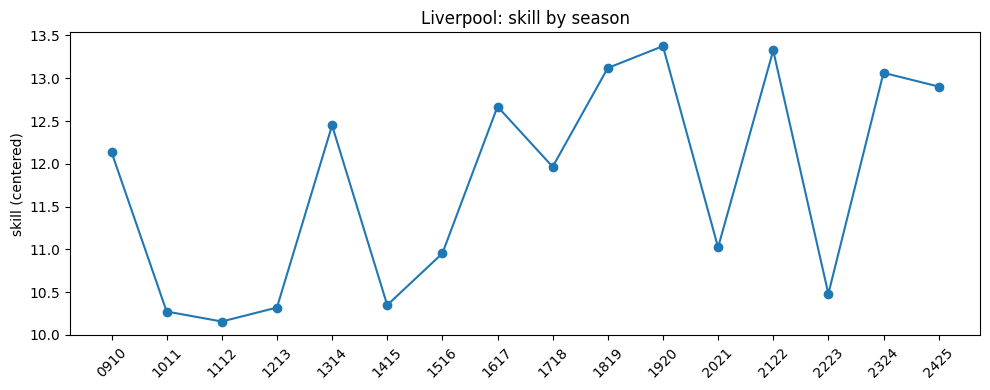

In [7]:
example_team = "Liverpool"
if example_team in team_to_idx:
    j = team_to_idx[example_team] - 1
    skill_ts = fit.stan_variable("skill")[:, :, j].mean(axis=0)
    seasons = list(season_to_idx.keys())
    plt.figure(figsize=(10, 4))
    plt.plot(seasons, skill_ts, marker="o")
    plt.xticks(rotation=45)
    plt.ylabel("skill (centered)")
    plt.title(f"{example_team}: skill by season")
    plt.tight_layout()
    plt.show()


### Posterior predictive check (PPC)

Simulate **replicated team-season points** from the posterior (Student-$t$ likelihood).
Compare the distribution and simple test statistics (mean, SD, min, max) to observed training points.
$p \approx 0.5$ suggests good calibration; values near 0 or 1 flag misfit.


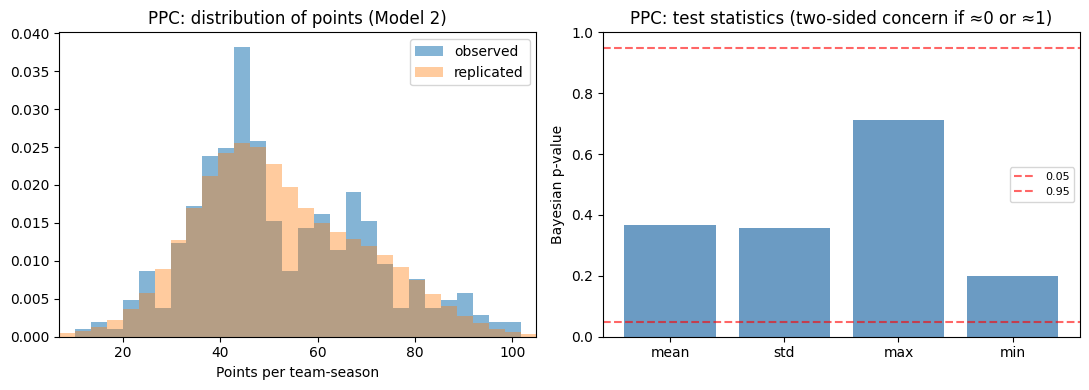

PPC x-axis shown: 6.8 to 105.0 points
Replicated draws outside shown range: 0.44%
  mean: p = 0.367
  std: p = 0.356
  max: p = 0.712
  min: p = 0.199


In [8]:
from helping_functions import ppc_table_replicates

y_obs = stan_data["pts"]
y_rep = ppc_table_replicates(fit, stan_data, model="hierarchical")
y_rep_flat = y_rep.reshape(-1)

# Focus the PPC plot on the observed range and the central model mass.
# Student-t tails can create rare extreme draws that otherwise stretch the x-axis.
q_low, q_high = np.quantile(y_rep_flat, [0.005, 0.995])
plot_low = max(0, min(y_obs.min(), q_low) - 5)
plot_high = min(110, max(y_obs.max(), q_high) + 5)
bins = np.linspace(plot_low, plot_high, 31)
outside = np.mean((y_rep_flat < plot_low) | (y_rep_flat > plot_high))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(y_obs, bins=bins, density=True, alpha=0.55, label="observed")
axes[0].hist(y_rep_flat, bins=bins, density=True, alpha=0.4, label="replicated")
axes[0].set_xlim(plot_low, plot_high)
axes[0].set_xlabel("Points per team-season")
axes[0].set_title("PPC: distribution of points (Model 2)")
axes[0].legend()

stats = {"mean": np.mean, "std": np.std, "max": np.max, "min": np.min}
pvals = {}
for name, fn in stats.items():
    obs_val = fn(y_obs)
    rep_vals = fn(y_rep, axis=1)
    pvals[name] = float((rep_vals >= obs_val).mean())

axes[1].bar(pvals.keys(), pvals.values(), color="steelblue", alpha=0.8)
axes[1].axhline(0.05, color="red", ls="--", alpha=0.6, label="0.05")
axes[1].axhline(0.95, color="red", ls="--", alpha=0.6, label="0.95")
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("Bayesian p-value")
axes[1].set_title("PPC: test statistics (two-sided concern if ≈0 or ≈1)")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"PPC x-axis shown: {plot_low:.1f} to {plot_high:.1f} points")
print(f"Replicated draws outside shown range: {100 * outside:.2f}%")
for name, p in pvals.items():
    print(f"  {name}: p = {p:.3f}")


**PPC interpretation (Model 2):** same logic as Model 1. If replicated points are too narrow or too wide relative to observed points, the likely culprits are `sigma_pts`, `tau_team`, or `tau_season`. If promoted teams are systematically overpredicted, inspect `beta_promoted`. Good PPC behavior means the hierarchical decomposition still reproduces the empirical distribution of table points, not only the parameter diagnostics.

### Predict table 2025/26


In [9]:
forecast_features = build_forecast_features(
    matches, LAST_TRAIN_SEASON, test_teams, TRAIN_SEASONS, feature_stats
)

pred_table = predict_table(
    fit,
    test_teams,
    team_to_idx,
    model="hierarchical",
    last_season_index=last_season_idx,
    team_features=forecast_features,
    n_sims=500,
    seed=42,
)

actual = compute_table(matches, TEST_SEASON)[["team", "position", "Pts"]]
actual = actual.rename(columns={"position": "pos_actual", "Pts": "pts_actual"})

comparison = pred_table.merge(actual, on="team", how="left")
comparison["pos_error"] = comparison["pos_median"] - comparison["pos_actual"]
comparison.sort_values("pos_actual")


,team,pos_median,pos_mean,pts_median,pts_mean,pos_actual,pts_actual,pos_error
1,Arsenal,3.0,4.180,69.940865,69.858636,1,85,2.0
0,Man City,2.0,2.288,78.551892,78.312516,2,78,0.0
4,Man United,5.0,5.914,64.323127,64.406330,3,71,2.0
6,Aston Villa,10.0,10.490,53.105320,53.357754,4,65,6.0
2,Liverpool,3.0,4.032,70.373622,70.224090,5,60,-2.0
8,Bournemouth,11.0,11.104,51.533010,52.135111,6,57,5.0
17,Sunderland,18.0,16.560,38.434955,38.751289,7,54,11.0
7,Brighton,10.0,10.498,53.199991,53.474629,8,53,2.0
9,Brentford,11.0,11.410,51.491626,51.192541,9,53,2.0
3,Chelsea,4.0,4.986,67.356060,67.367288,10,52,-6.0


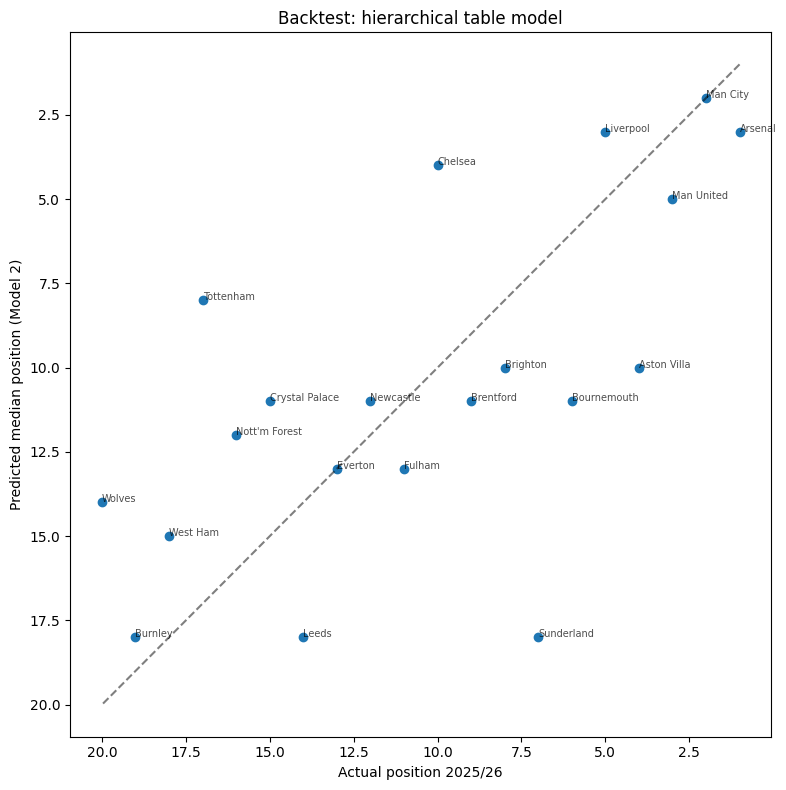

MAE position: 3.60


In [10]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(comparison["pos_actual"], comparison["pos_median"])
for _, r in comparison.iterrows():
    ax.annotate(r["team"], (r["pos_actual"], r["pos_median"]), fontsize=7, alpha=0.7)
ax.plot([1, 20], [1, 20], "k--", alpha=0.5)
ax.set_xlabel("Actual position 2025/26")
ax.set_ylabel("Predicted median position (Model 2)")
ax.set_title("Backtest: hierarchical table model")
ax.invert_xaxis()
ax.invert_yaxis()
plt.tight_layout()
plt.show()
print(f"MAE position: {comparison['pos_error'].abs().mean():.2f}")


### WAIC / LOO

This is a single-model diagnostic version of the information criteria. The final comparison between Model 1 and Model 2 is done in notebook `04` on the same team-season rows.

For PSIS-LOO, check `pareto_k`: values $\leq 0.7$ are reliable; values above 0.7 indicate influential team-seasons. For WAIC, warnings about high posterior variance of log predictive density mean WAIC may be less stable, so PSIS-LOO and the rolling backtest should receive more weight.

In [11]:
idata = az.from_cmdstanpy(fit)
print(az.waic(idata))
loo = az.loo(idata, pointwise=True)
print(loo)

k = loo.pareto_k.values
n_good = int((k <= 0.7).sum())
n_bad = int(((k > 0.7) & (k <= 1)).sum())
n_very_bad = int((k > 1).sum())
print(f"\nPareto k: good (≤0.7) {n_good}/{len(k)} ({100 * n_good / len(k):.1f}%)")
print(f"           bad (0.7–1] {n_bad}, very bad (>1) {n_very_bad}")


Computed from 6000 posterior samples and 320 observations log-likelihood matrix.

          Estimate       SE
elpd_waic -1223.31    15.68
p_waic       76.00        -

There has been a warning during the calculation. Please check the results.


/usr/local/lib/python3.11/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


Computed from 6000 posterior samples and 320 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -1224.37    15.64
p_loo       77.07        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      320  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%


Pareto k: good (≤0.7) 320/320 (100.0%)
           bad (0.7–1] 0, very bad (>1) 0
